Saved on-sky plot for zach to zach_on_sky_view.png


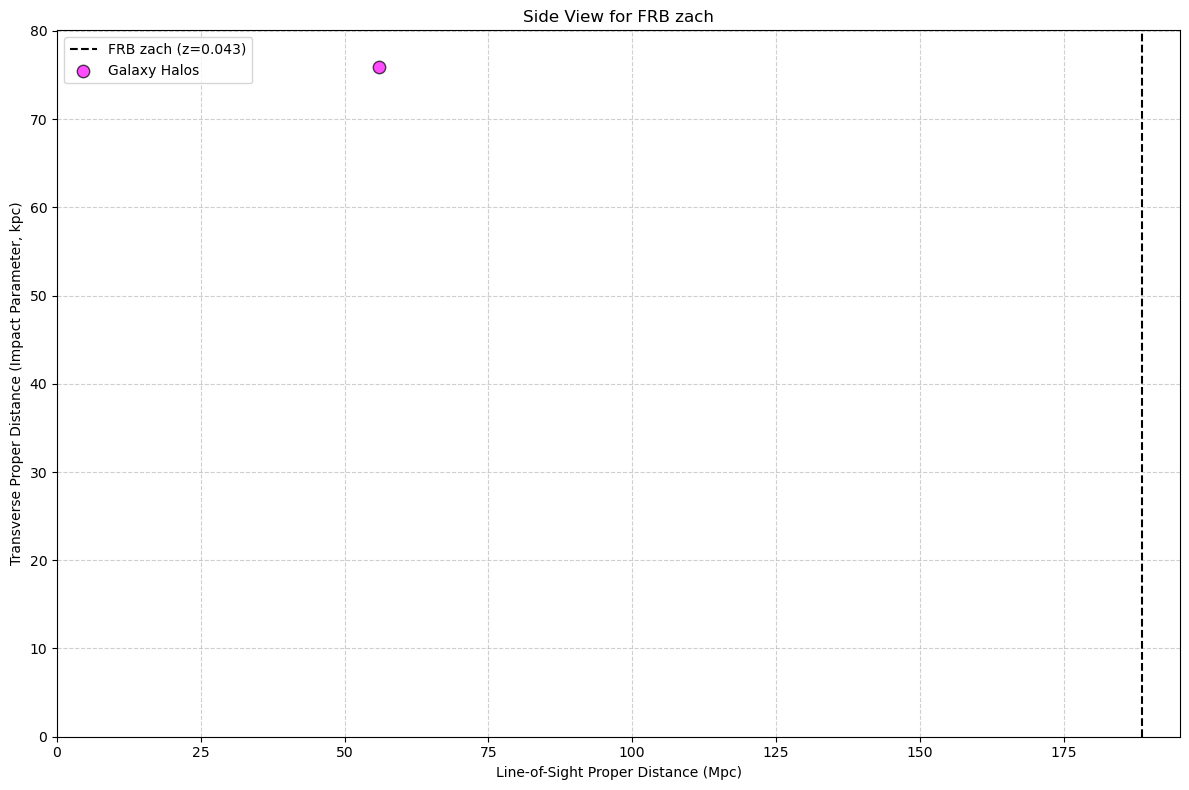

Saved side-view plot for zach to zach_side_view.png
Saved on-sky plot for whitney to whitney_on_sky_view.png


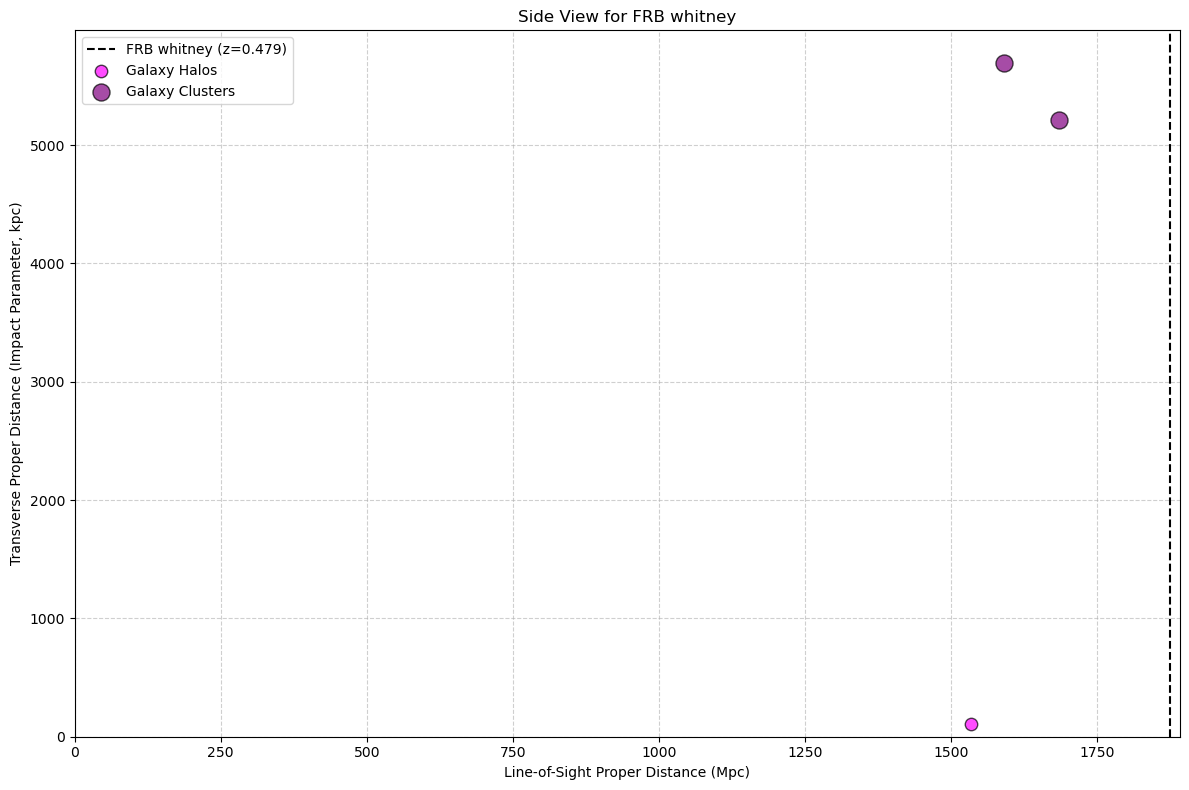

Saved side-view plot for whitney to whitney_side_view.png
Saved on-sky plot for oran to oran_on_sky_view.png


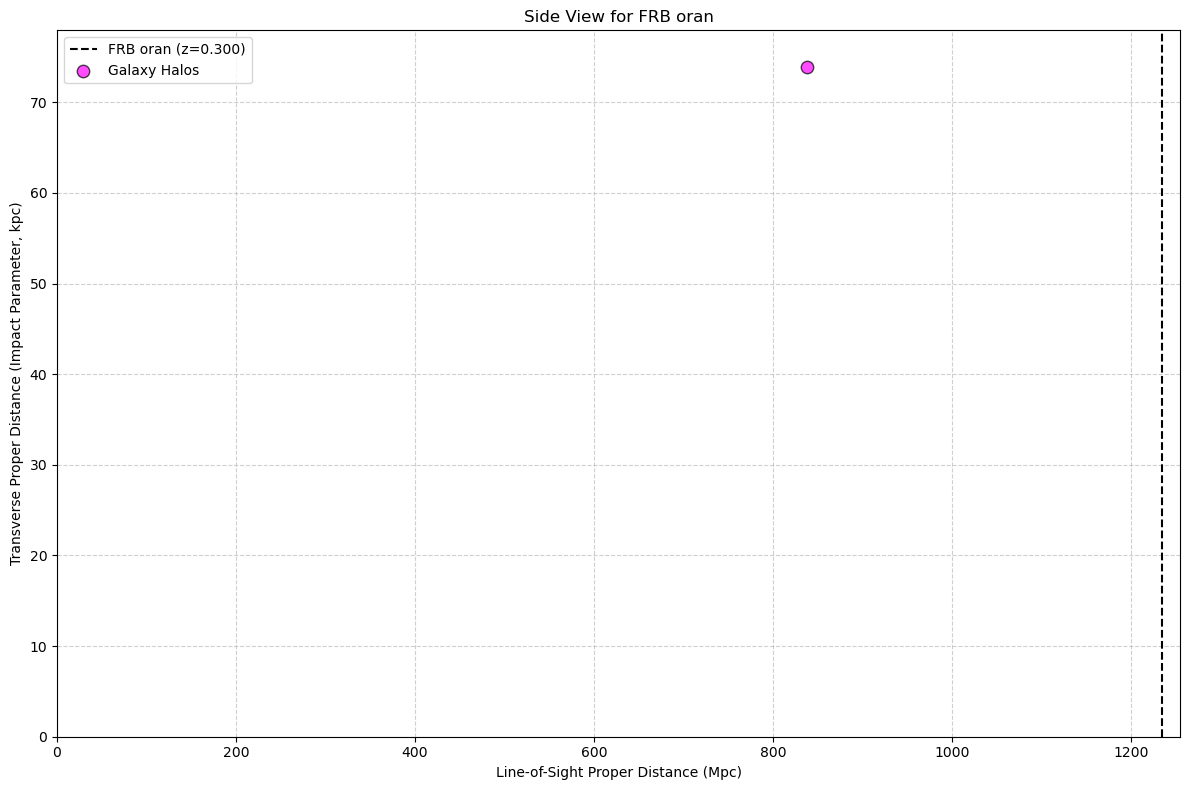

Saved side-view plot for oran to oran_side_view.png
No valid foreground objects found for FRB wilhelm. Skipping.
Saved on-sky plot for phineas to phineas_on_sky_view.png


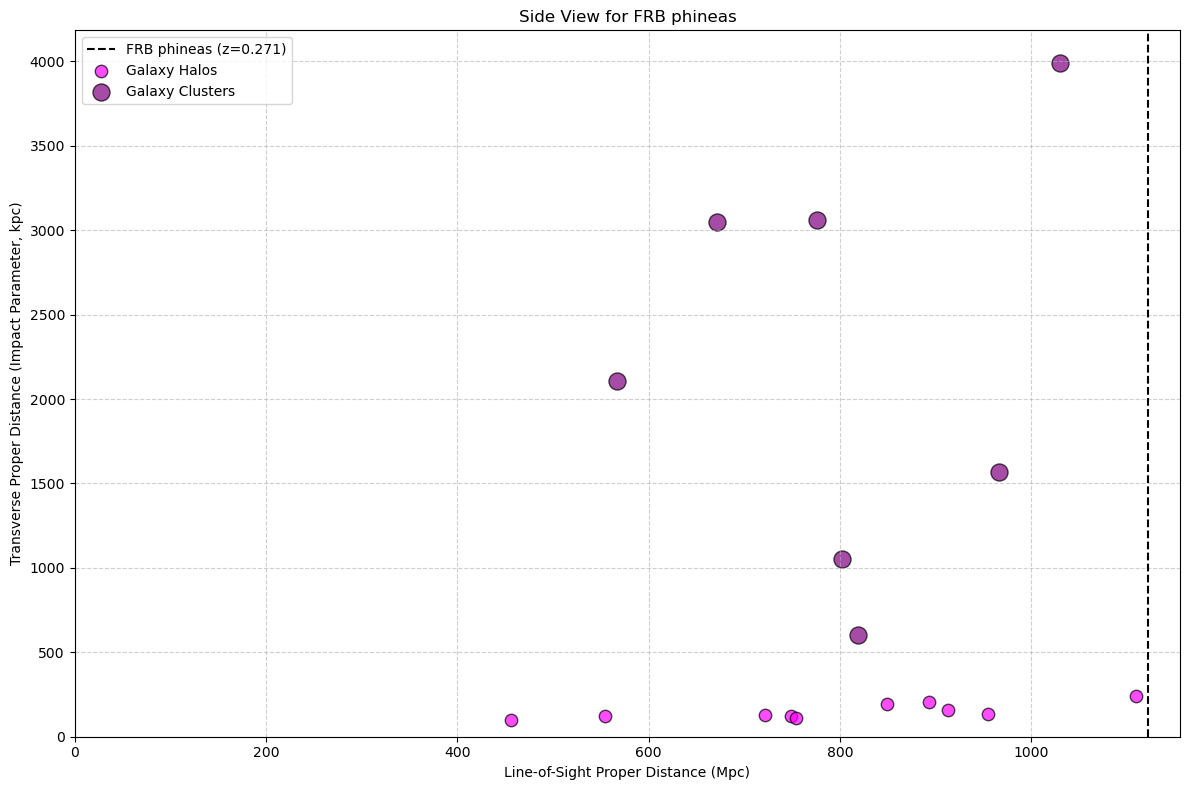

Saved side-view plot for phineas to phineas_side_view.png
No valid foreground objects found for FRB freya. Skipping.
Saved on-sky plot for hamilton to hamilton_on_sky_view.png


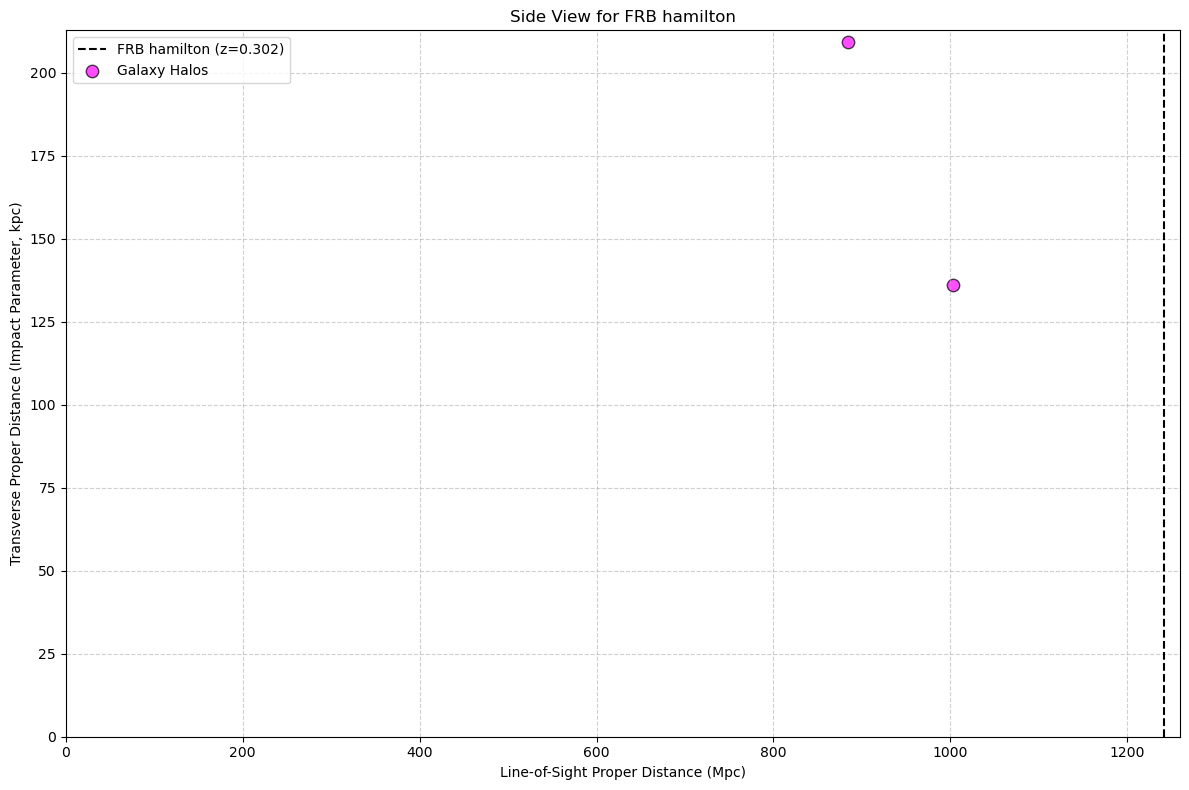

Saved side-view plot for hamilton to hamilton_side_view.png
Saved on-sky plot for chromatica to chromatica_on_sky_view.png


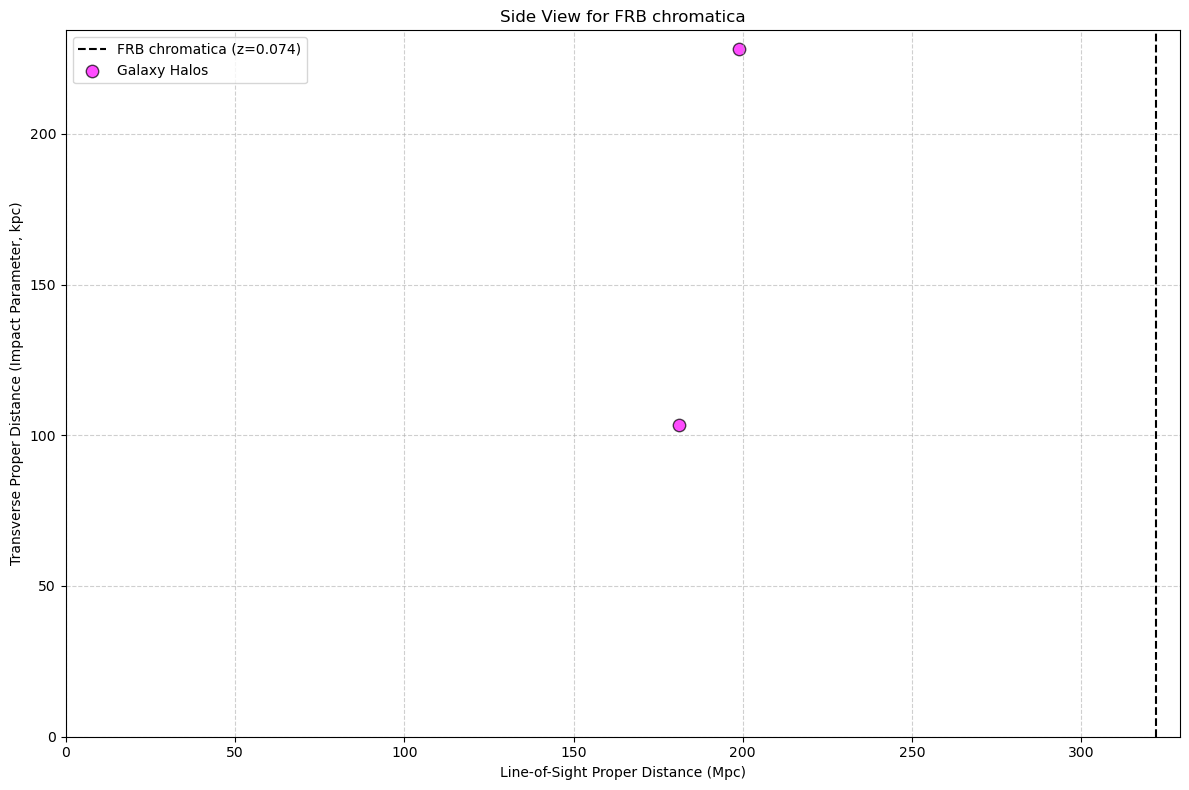

Saved side-view plot for chromatica to chromatica_side_view.png
Saved on-sky plot for casey to casey_on_sky_view.png


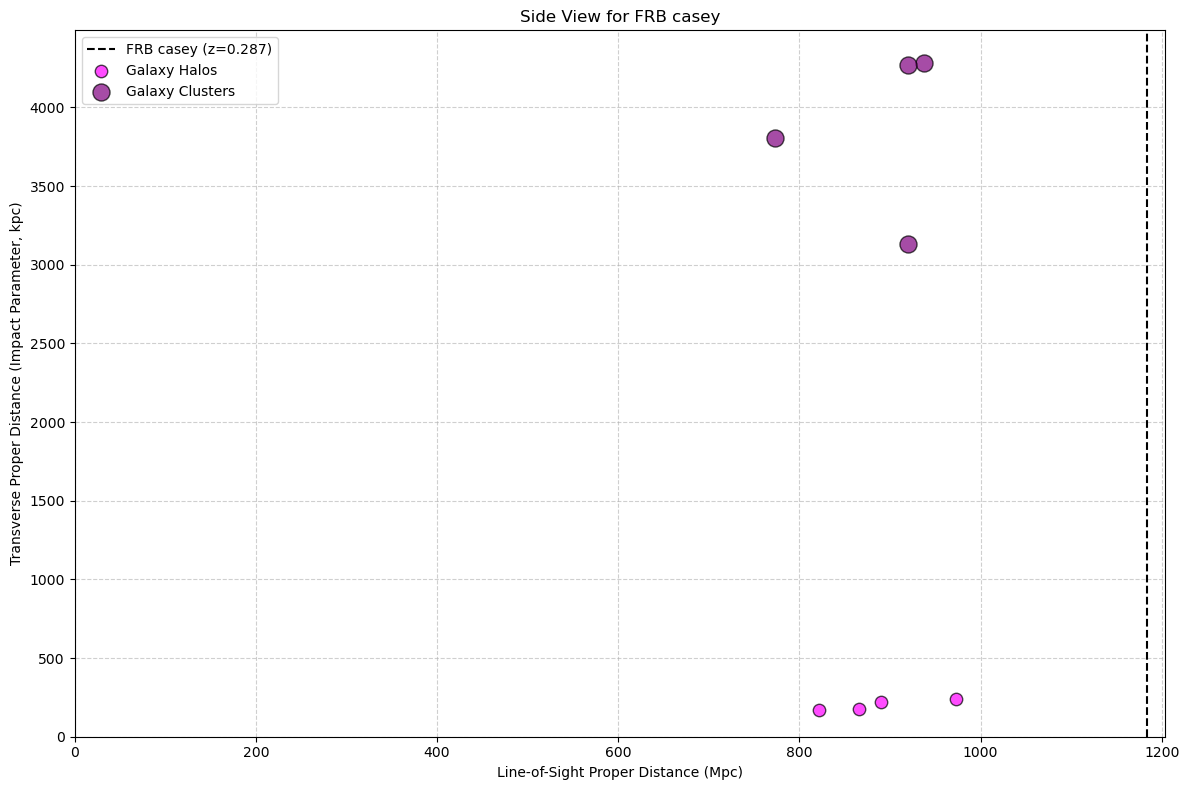

Saved side-view plot for casey to casey_side_view.png


In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import SkyCoord
import warnings

# Suppress minor warnings from matplotlib about plotting very small circles
warnings.filterwarnings("ignore", message="The radius of the circle is smaller than 5 pixels.")

DATA_DIR = Path("notebooks/codetections/data")
if not DATA_DIR.exists():
    DATA_DIR = Path("data")

def plot_frb_foregrounds(frb_name, frb_data, halos, clusters):
    """
    Generates two plots for a single FRB:
    1. On-sky view (RA vs. Dec).
    2. Side view (Transverse vs. Line-of-sight distance).
    """
    if halos.empty and clusters.empty:
        print(f"No valid foreground objects found for FRB {frb_name}. Skipping.")
        return

    # Extract FRB properties from the first row of the provided data
    frb_ra = frb_data['RA_deg'].iloc[0]
    frb_dec = frb_data['Dec_deg'].iloc[0]
    frb_z = frb_data['z_spectroscopic'].iloc[0]

    # --- Plot 1: On-sky View (RA vs. Dec) ---
    fig1, ax1 = plt.subplots(figsize=(10, 10), dpi=100)

    # Plot FRB position
    ax1.plot(frb_ra, frb_dec, '*', color='black', markersize=20, label=f'FRB {frb_name}', zorder=10)

    # Collect all coordinates to set plot limits
    all_ras = [frb_ra]
    all_decs = [frb_dec]

    # Plot foreground halos
    for _, halo in halos.iterrows():
        halo_ra = halo['halo_RA_deg']
        halo_dec = halo['halo_Dec_deg']
        halo_z = halo['halo_z_photometric']
        
        # Calculate angular radius of a 200 kpc halo at its redshift
        ang_diam_dist = cosmo.angular_diameter_distance(halo_z)
        phys_radius = 200 * u.kpc
        # Apply dimensionless_angles() equivalency to convert the dimensionless ratio to an angle
        angular_radius = (phys_radius / ang_diam_dist).to(u.deg, equivalencies=u.dimensionless_angles()).value
        
        # Plot halo as a magenta circle
        halo_circle = Circle((halo_ra, halo_dec), radius=angular_radius,
                             edgecolor='magenta', facecolor='magenta', alpha=0.3,
                             label='Galaxy Halo (200 kpc)' if 'Galaxy Halo' not in [p.get_label() for p in ax1.patches] else "")
        ax1.add_patch(halo_circle)
        all_ras.extend([halo_ra - angular_radius, halo_ra + angular_radius])
        all_decs.extend([halo_dec - angular_radius, halo_dec + angular_radius])

    # Plot foreground clusters
    for _, cluster in clusters.iterrows():
        cluster_ra = cluster['cluster_RA_deg']
        cluster_dec = cluster['cluster_Dec_deg']
        cluster_z = cluster['cluster_z_photometric']
        r500_mpc = cluster['r500_Mpc']
        
        # Calculate angular radius of the cluster (R_500) at its redshift
        ang_diam_dist = cosmo.angular_diameter_distance(cluster_z)
        phys_radius = r500_mpc * u.Mpc
        # Apply dimensionless_angles() equivalency to convert the dimensionless ratio to an angle
        angular_radius = (phys_radius / ang_diam_dist).to(u.deg, equivalencies=u.dimensionless_angles()).value
        
        # Plot cluster as a purple circle
        cluster_circle = Circle((cluster_ra, cluster_dec), radius=angular_radius,
                                edgecolor='purple', facecolor='purple', alpha=0.3,
                                label='Galaxy Cluster (R_500)' if 'Galaxy Cluster' not in [p.get_label() for p in ax1.patches] else "")
        ax1.add_patch(cluster_circle)
        all_ras.extend([cluster_ra - angular_radius, cluster_ra + angular_radius])
        all_decs.extend([cluster_dec - angular_radius, cluster_dec + angular_radius])

    # Set plot limits and appearance
    ra_min, ra_max = min(all_ras), max(all_ras)
    dec_min, dec_max = min(all_decs), max(all_decs)
    ra_range = ra_max - ra_min
    dec_range = dec_max - dec_min
    buffer = max(ra_range, dec_range) * 0.1
    
    ax1.set_xlim(ra_max + buffer, ra_min - buffer) # Invert RA axis
    ax1.set_ylim(dec_min - buffer, dec_max + buffer)
    ax1.set_xlabel('Right Ascension (degrees)')
    ax1.set_ylabel('Declination (degrees)')
    ax1.set_title(f'On-Sky View for FRB {frb_name}')
    ax1.legend()
    ax1.set_aspect('equal', adjustable='box')
    ax1.grid(True, linestyle='--', alpha=0.6)
    fig1.tight_layout()
    fig1.savefig(f"{frb_name}_on_sky_view.png")
    plt.close(fig1)
    print(f"Saved on-sky plot for {frb_name} to {frb_name}_on_sky_view.png")


    # --- Plot 2: Side View (Proper Distance) ---
    fig2, ax2 = plt.subplots(figsize=(12, 8), dpi=100)

    # Calculate FRB line-of-sight distance
    frb_los_dist = cosmo.comoving_distance(frb_z).to(u.Mpc).value
    ax2.axvline(frb_los_dist, color='black', linestyle='--', label=f'FRB {frb_name} (z={frb_z:.3f})')
    
    # Plot halos
    if not halos.empty:
        halo_los_dist = cosmo.comoving_distance(halos['halo_z_photometric']).to(u.Mpc).value
        halo_impact_param = halos['halo_Impact_Parameter_kpc']
        ax2.scatter(halo_los_dist, halo_impact_param, c='magenta', s=80, alpha=0.7, edgecolors='black', label='Galaxy Halos')

    # Plot clusters
    if not clusters.empty:
        cluster_los_dist = cosmo.comoving_distance(clusters['cluster_z_photometric']).to(u.Mpc).value
        cluster_impact_param = clusters['cluster_Impact_Parameter_kpc']
        ax2.scatter(cluster_los_dist, cluster_impact_param, c='purple', s=150, alpha=0.7, edgecolors='black', label='Galaxy Clusters')
        
    # Set plot limits and appearance
    ax2.set_xlabel('Line-of-Sight Proper Distance (Mpc)')
    ax2.set_ylabel('Transverse Proper Distance (Impact Parameter, kpc)')
    ax2.set_title(f'Side View for FRB {frb_name}')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.set_ylim(bottom=0) # Impact parameter is always positive
    ax2.set_xlim(left=0)
    fig2.tight_layout()
    plt.show()
    fig2.savefig(f"{frb_name}_side_view.png")
    plt.close(fig2)
    print(f"Saved side-view plot for {frb_name} to {frb_name}_side_view.png")


def main():
    """
    Main function to load data, filter, and generate plots for each FRB.
    """
    try:
        df_halos = pd.read_csv(DATA_DIR / 'frb_halo_associations.csv')
        df_clusters = pd.read_csv(DATA_DIR / 'frb_cluster_associations.csv')
    except FileNotFoundError as e:
        print(f"Error: {e}. Please ensure the cleaned CSV files exist.")
        return

    # Get a list of all unique FRB names from both dataframes
    all_frb_names = pd.concat([df_halos['name'], df_clusters['name']]).unique()

    # Loop through each FRB and generate plots
    for frb_name in all_frb_names:
        # Get all data associated with the current FRB
        frb_halo_data = df_halos[df_halos['name'] == frb_name]
        frb_cluster_data = df_clusters[df_clusters['name'] == frb_name]
        
        # Combine data to get the FRB's redshift (it's the same in both files)
        frb_all_data = pd.concat([frb_halo_data, frb_cluster_data])
        if frb_all_data.empty:
            continue
            
        frb_z_spec = frb_all_data['z_spectroscopic'].iloc[0]
        
        # Filter halos and clusters to be foreground only
        filtered_halos = frb_halo_data[frb_halo_data['halo_z_photometric'] < frb_z_spec].copy()
        filtered_clusters = frb_cluster_data[frb_cluster_data['cluster_z_photometric'] < frb_z_spec].copy()
        
        plot_frb_foregrounds(frb_name, frb_all_data, filtered_halos, filtered_clusters)

if __name__ == '__main__':
    main()

